En este scripts, vamos a predecir el redshift utilizando 
una regresión simple con el Modelo de Random Forest.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().resolve().parent))
from preprocess_vae import load_features

In [2]:
df = load_features()

Filtros de catálogo:
  inicial            : 29575
  maskbits==0        : 27757
  flujo>0 (griz)     : 26166
  profundidad (mag)  : 21340
  SNR>=3 (griz)      : 21287


In [3]:
df.columns

Index(['desi_id', 'mean_fiber_ra', 'mean_fiber_dec', 'z', 'zerr', 'ra', 'dec',
       'type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic', 'ebv', 'brickid',
       'dchisq_psf', 'dchisq_rex', 'dchisq_exp', 'dchisq_dev', 'dchisq_ser',
       'id', 'flux_g', 'flux_r', 'flux_i', 'flux_z', 'flux_w1', 'flux_w2',
       'flux_w3', 'flux_w4', 'flux_ivar_g', 'flux_ivar_r', 'flux_ivar_i',
       'flux_ivar_z', 'flux_ivar_w1', 'flux_ivar_w2', 'flux_ivar_w3',
       'flux_ivar_w4', 'mw_transmission_i', 'fitbits', 'mw_transmission_w1',
       'brickname', 'mw_transmission_z', 'mw_transmission_g', 'maskbits',
       'mw_transmission_w2', 'mw_transmission_w3', 'objid',
       'mw_transmission_w4', 'mw_transmission_r', 'mag_g_corr', 'mag_r_corr',
       'mag_i_corr', 'mag_z_corr', 'SNR_g', 'SNR_r', 'SNR_i', 'SNR_z'],
      dtype='str')

In [4]:
df['mag_w1_corr'] = df['flux_w1']/df['mw_transmission_w1']
df['mag_w2_corr'] = df['flux_w2']/df['mw_transmission_w2']
df['mag_w3_corr'] = df['flux_w3']/df['mw_transmission_w3']
df['mag_w4_corr'] = df['flux_w4']/df['mw_transmission_w4']

In [5]:
df = df[['type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic', "mag_g_corr", "mag_r_corr", "mag_i_corr", "mag_z_corr", "mag_w1_corr", "mag_w2_corr", "mag_w3_corr", "mag_w4_corr",'z']]
df.dropna(inplace=True)
X = df.drop(columns=['z'])
y = df['z']

In [6]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
def compute_photoz_metrics(z_true, z_pred, threshold=0.05, label=None):
    """Métricas estándar de photo-z: residuos normalizados, sigma_MAD y tasa de outliers catastróficos."""
    z_true = np.asarray(z_true, dtype=float)
    z_pred = np.asarray(z_pred, dtype=float)

    # Residuo normalizado: Δz = (z_pred - z_true) / (1 + z_true)
    delta_z = (z_pred - z_true) / (1 + z_true)

    bias = delta_z.mean()
    std = delta_z.std()
    sigma_mad = 1.4826 * np.median(np.abs(delta_z - np.median(delta_z)))
    eta = (np.abs(delta_z) > threshold).mean() * 100

    if label:
        print(f"--- Métricas photo-z: {label} ---")
    print(f"<Δz> (bias)              = {bias:.5f}")
    print(f"std(Δz)                  = {std:.5f}")
    print(f"σ_MAD                    = {sigma_mad:.5f}")
    print(f"η [%] (|Δz| > {threshold})     = {eta:.3f}")

    return {"delta_z": delta_z, "bias": bias, "std": std, "sigma_mad": sigma_mad, "eta": eta}


def plot_specz_vs_photoz(z_true, z_pred, threshold=0.05, title=None, ax=None):
    """Scatter z_spec vs z_phot con línea 1:1 (punteada) y límites de error catastrófico (rojo, lw=5)."""
    z_true = np.asarray(z_true, dtype=float)
    z_pred = np.asarray(z_pred, dtype=float)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))

    ax.scatter(z_true, z_pred, alpha=0.4, s=4)

    lo = min(z_true.min(), z_pred.min())
    hi = max(z_true.max(), z_pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=2, label="1:1")

    z_line = np.linspace(lo, hi, 200)
    ax.plot(z_line, z_line + threshold * (1 + z_line), color="red", lw=2,
            label=f"Límite error catastrófico (|Δz| > {threshold})")
    ax.plot(z_line, z_line - threshold * (1 + z_line), color="red", lw=2)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Redshift espectroscópico")
    ax.set_ylabel("Redshift fotométrico predicho")
    if title:
        ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)

    return ax

In [10]:
# Considerando el problema como regresión

X = X.copy()
y = df["z"].copy()

numeric_features = [c for c in X.columns if c != "type"]
categorical_features = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=124
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=10,
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# Residuos normalizados, σ_MAD y η
reg_metrics_v1 = compute_photoz_metrics(y_test.to_numpy(), y_pred, label="Regresión (sin colores)")

MAE:  0.0841
RMSE: 0.1504
R2:   0.8549
--- Métricas photo-z: Regresión (sin colores) ---
<Δz> (bias)              = 0.00719
std(Δz)                  = 0.10147
σ_MAD                    = 0.04639
η [%] (|Δz| > 0.05)     = 31.775


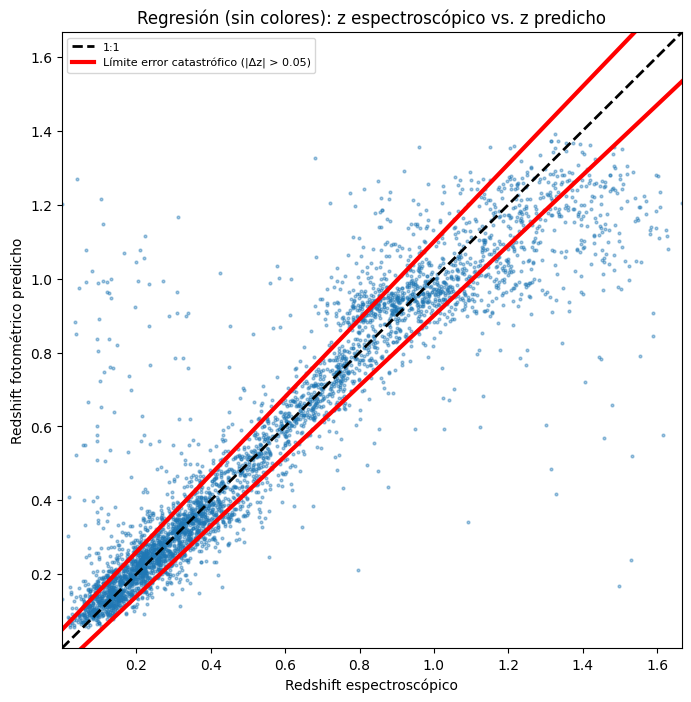

In [11]:
plot_specz_vs_photoz(
    y_test.to_numpy(), y_pred,
    threshold=0.05,
    title="Regresión (sin colores): z espectroscópico vs. z predicho"
)
plt.show()

In [13]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 16.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 614.2/614.2 kB 5.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [optuna]2m5/6 [optuna]]my]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
## Optimización de hiperparámetros
import optuna

/home/tamara/hips-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
